<a href="https://colab.research.google.com/github/yakubavm/monitoring_of_production_processes/blob/LR_2/LR_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from typing import List, Tuple

# Налаштування стилю графіків
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

class VariabilityAnalyzer:
    """
    Клас-аналізатор для виявлення грубих помилок (викидів) та розрахунку
    довірчих інтервалів згідно з методикою лабораторної роботи №2.
    """

    # Таблиця 2.1 - Значення r_max (або r_min) для P=0.95
    # Ключ: f (ступені свободи = n - 1), Значення: критичне значення r
    R_CRITICAL_TABLE = {
        1: 1.412, 2: 1.689, 3: 1.869, 4: 1.996, 5: 2.093,
        6: 2.172, 7: 2.237, 8: 2.294, 9: 2.343, 10: 2.387,
        11: 2.426, 12: 2.461, 13: 2.493, 14: 2.523, 15: 2.551,
        16: 2.577, 17: 2.600, 18: 2.623, 19: 2.644, 20: 2.664,
        21: 2.683, 22: 2.701, 23: 2.717
    }

    @staticmethod
    def calculate_cv(data: np.ndarray) -> float:
        """
        Обчислює коефіцієнт варіації у відсотках (формула 2.4).
        Використовується вибіркове стандартне відхилення (ddof=1).
        """
        mean_val = np.mean(data)
        std_val = np.std(data, ddof=1)
        return (std_val / mean_val) * 100

    @classmethod
    def get_r_critical(cls, f: int) -> float:
        """
        Отримує табличне значення r-критерію.
        Якщо значення f виходить за межі таблиці, використовується наближення Граббса.
        """
        return cls.R_CRITICAL_TABLE.get(f, 3.0) # 3.0 як безпечне резервне значення для великих вибірок

In [2]:
# Завдання 1: Генерувати вибірку з 20 випадкових значень у діапазоні [1…10]
# (нормальний розподіл). Обчислити коефіцієнт варіації.
print("-" * 60)
print("ВИКОНАННЯ ЗАВДАННЯ 1: Генерація нормального розподілу")
print("-" * 60)

np.random.seed(15) # Фіксація seed для відтворюваності (номер варіанта: 15)

# Генерування нормального розподілу з відсіканням значень поза діапазоном [1, 10]
# Математичне очікування = 5.5, стандартне відхилення = 2.0
base_sample = np.random.normal(loc=5.5, scale=2.0, size=20)
base_sample = np.clip(base_sample, 1.0, 10.0) # Забезпечення жорстких меж [1; 10]

# Розрахунок коефіцієнта варіації
cv_initial = VariabilityAnalyzer.calculate_cv(base_sample)

print(f"Згенерована початкова вибірка (n=20):\n{np.round(base_sample, 2)}")
print(f"Початковий коефіцієнт варіації: {cv_initial:.2f}%")

if cv_initial <= 33.0:
    print("Висновок: Сукупність вважається однорідною (V <= 33%).")
else:
    print("Висновок: Сукупність неоднорідна (V > 33%).")
print("\n")

------------------------------------------------------------
ВИКОНАННЯ ЗАВДАННЯ 1: Генерація нормального розподілу
------------------------------------------------------------
Згенерована початкова вибірка (n=20):
[4.88 6.18 5.19 4.5  5.97 1.97 3.31 3.32 4.89 4.55 5.1  6.21 6.88 6.32
 4.37 6.7  5.17 8.7  6.86 5.53]
Початковий коефіцієнт варіації: 28.23%
Висновок: Сукупність вважається однорідною (V <= 33%).




In [3]:
# Завдання 2: Додати три значення, які відрізняються від max в 1,3…1,6 разів.
print("-" * 60)
print("ВИКОНАННЯ ЗАВДАННЯ 2: Штучне внесення грубих помилок (викидів)")
print("-" * 60)

max_val = np.max(base_sample)

# Генерація трьох викидів згідно з умовою: max * [1.3 ... 1.6]
outliers = [
    max_val * 1.35,
    max_val * 1.48,
    max_val * 1.55
]

# Об'єднання базової вибірки та викидів
dirty_sample = np.append(base_sample, outliers)

# Повторний розрахунок коефіцієнта варіації
cv_dirty = VariabilityAnalyzer.calculate_cv(dirty_sample)

print(f"Максимальне значення у базовій вибірці: {max_val:.2f}")
print(f"Згенеровані грубі помилки: {np.round(outliers, 2)}")
print(f"Новий коефіцієнт варіації: {cv_dirty:.2f}%")
print(f"Зростання варіативності на {cv_dirty - cv_initial:.2f}% свідчить про наявність аномалій.\n")

------------------------------------------------------------
ВИКОНАННЯ ЗАВДАННЯ 2: Штучне внесення грубих помилок (викидів)
------------------------------------------------------------
Максимальне значення у базовій вибірці: 8.70
Згенеровані грубі помилки: [11.75 12.88 13.49]
Новий коефіцієнт варіації: 46.26%
Зростання варіативності на 18.03% свідчить про наявність аномалій.



In [4]:
# Завдання 3: Почергово знайти та виключити «викиди» (r-критерій).
print("-" * 60)
print("ВИКОНАННЯ ЗАВДАННЯ 3: Алгоритм фільтрації за r-критерієм")
print("-" * 60)

cleaned_list = dirty_sample.tolist()
iteration = 1

# Реалізація ітеративного алгоритму згідно з формулами 2.1 - 2.3 методички
while True:
    n = len(cleaned_list)
    mean_val = np.mean(cleaned_list)
    std_val = np.std(cleaned_list, ddof=1)

    # Пошук елемента, що найбільше відрізняється від середнього
    deviations = [abs(x - mean_val) / std_val for x in cleaned_list]
    max_dev_idx = int(np.argmax(deviations))

    r_calc = deviations[max_dev_idx]
    suspect_value = cleaned_list[max_dev_idx]

    # Визначення ступенів свободи та критичного значення
    f = n - 1
    r_crit = VariabilityAnalyzer.get_r_critical(f)

    print(f"--- Ітерація {iteration} ---")
    print(f"n={n}, f={f}, Середнє={mean_val:.2f}, Відхилення s={std_val:.2f}")
    print(f"Підозріле значення: {suspect_value:.2f}")
    print(f"Розрахований r-критерій: {r_calc:.3f} | Табличний r-критерій: {r_crit:.3f}")

    if r_calc > r_crit:
        print(f"РІШЕННЯ: {r_calc:.3f} > {r_crit:.3f} -> Значення {suspect_value:.2f} є ГРУБОЮ ПОМИЛКОЮ. Виключено.")
        cleaned_list.pop(max_dev_idx)
        iteration += 1
    else:
        print(f"РІШЕННЯ: {r_calc:.3f} <= {r_crit:.3f} -> Грубих помилок більше не виявлено. Зупинка алгоритму.")
        break

cleaned_sample = np.array(cleaned_list)
print("\nФільтрація успішно завершена.")

------------------------------------------------------------
ВИКОНАННЯ ЗАВДАННЯ 3: Алгоритм фільтрації за r-критерієм
------------------------------------------------------------
--- Ітерація 1 ---
n=23, f=22, Середнє=6.29, Відхилення s=2.91
Підозріле значення: 13.49
Розрахований r-критерій: 2.472 | Табличний r-критерій: 2.701
РІШЕННЯ: 2.472 <= 2.701 -> Грубих помилок більше не виявлено. Зупинка алгоритму.

Фільтрація успішно завершена.


------------------------------------------------------------
ВИКОНАННЯ ЗАВДАННЯ 4: Оцінка параметрів (Розподіл Стьюдента)
------------------------------------------------------------
Кількість елементів в очищеній вибірці (n): 23
Ступені свободи (f): 22
Табличний коефіцієнт Стьюдента (t): 2.07
Вибіркове стандартне відхилення (s): 2.911
Абсолютна похибка (Δ): 1.259

ФІНАЛЬНИЙ РЕЗУЛЬТАТ:
Середнє значення з довірчим інтервалом: 6.29 ± 1.26
Істинне значення знаходиться в діапазоні: [5.03 ; 7.55] з імовірністю 95%


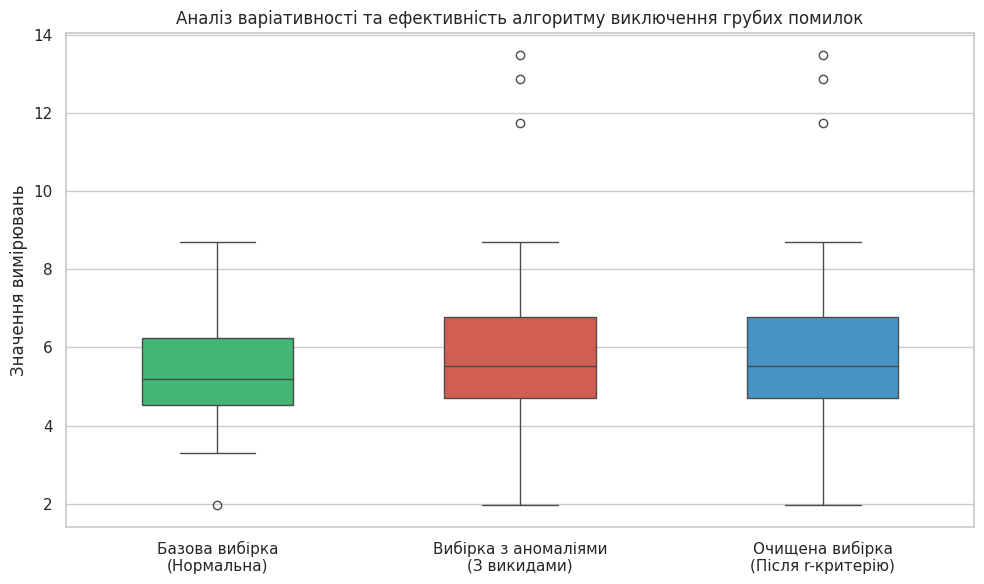

In [5]:
# Завдання 4: Розрахувати середнє значення й довірчий інтервал з Р=0.95.
print("-" * 60)
print("ВИКОНАННЯ ЗАВДАННЯ 4: Оцінка параметрів (Розподіл Стьюдента)")
print("-" * 60)

n_clean = len(cleaned_sample)
mean_clean = np.mean(cleaned_sample)
std_clean = np.std(cleaned_sample, ddof=1)

# Ступені свободи для t-розподілу
f_clean = n_clean - 1
alpha = 0.05 # Рівень значущості для P=0.95 (1 - 0.95)

# Розрахунок коефіцієнта Стьюдента (аналог Таблиці 2.2)
# Використовується двосторонній (two-tailed) критерій: 1 - alpha/2
t_value = stats.t.ppf(1 - alpha/2, df=f_clean)

# Обчислення довірчого інтервалу (формула 2.5)
delta = t_value * (std_clean / np.sqrt(n_clean))

print(f"Кількість елементів в очищеній вибірці (n): {n_clean}")
print(f"Ступені свободи (f): {f_clean}")
print(f"Табличний коефіцієнт Стьюдента (t): {t_value:.2f}")
print(f"Вибіркове стандартне відхилення (s): {std_clean:.3f}")
print(f"Абсолютна похибка (Δ): {delta:.3f}\n")

print("ФІНАЛЬНИЙ РЕЗУЛЬТАТ:")
print(f"Середнє значення з довірчим інтервалом: {mean_clean:.2f} ± {delta:.2f}")
print(f"Істинне значення знаходиться в діапазоні: [{mean_clean - delta:.2f} ; {mean_clean + delta:.2f}] з імовірністю 95%")

# Візуалізація: Порівняння вибірок Boxplot-ом
plt.figure(figsize=(10, 6))
data_to_plot = [base_sample, dirty_sample, cleaned_sample]
sns.boxplot(data=data_to_plot, width=0.5, palette=["#2ecc71", "#e74c3c", "#3498db"])
plt.xticks([0, 1, 2], ['Базова вибірка\n(Нормальна)', 'Вибірка з аномаліями\n(З викидами)', 'Очищена вибірка\n(Після r-критерію)'])
plt.ylabel('Значення вимірювань')
plt.title('Аналіз варіативності та ефективність алгоритму виключення грубих помилок')
plt.tight_layout()
plt.show()